# non-eq measure CDF

This notebook loads the processed experiment and simulation manifests, then plots the empirical CDF of `nonequilibrium_measure` for each domain separately.

- Experiment: `dataset/experiment/manifest.csv`
- Theory/Simulation: `dataset/simulation/manifest.csv`


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "dataset").exists() and (candidate / "README.md").exists():
            return candidate
    raise FileNotFoundError("Could not find the repository root from the current working directory.")


ROOT = find_repo_root()
OUTPUT_DIR = ROOT / "notebooks" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXP_PATH = ROOT / "dataset" / "experiment" / "manifest.csv"
SIM_PATH = ROOT / "dataset" / "simulation" / "manifest.csv"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 200

ROOT, EXP_PATH, SIM_PATH, OUTPUT_DIR


(PosixPath('/data1/bowenyu/XPCS_ODE'),
 PosixPath('/data1/bowenyu/XPCS_ODE/dataset/experiment/manifest.csv'),
 PosixPath('/data1/bowenyu/XPCS_ODE/dataset/simulation/manifest.csv'),
 PosixPath('/data1/bowenyu/XPCS_ODE/notebooks/outputs'))

In [2]:
def load_noneq_values(csv_path: Path) -> pd.Series:
    df = pd.read_csv(csv_path)
    values = pd.to_numeric(df["nonequilibrium_measure"], errors="coerce").dropna()
    return values.reset_index(drop=True)


exp_values = load_noneq_values(EXP_PATH)
sim_values = load_noneq_values(SIM_PATH)

summary_df = pd.DataFrame(
    [
        {
            "domain": "experiment",
            "count": len(exp_values),
            "min": exp_values.min(),
            "mean": exp_values.mean(),
            "median": exp_values.median(),
            "max": exp_values.max(),
        },
        {
            "domain": "theory",
            "count": len(sim_values),
            "min": sim_values.min(),
            "mean": sim_values.mean(),
            "median": sim_values.median(),
            "max": sim_values.max(),
        },
    ]
)

summary_df


,domain,count,min,mean,median,max
0,experiment,2232,0.111027,0.359814,0.308514,0.952207
1,theory,2000,0.000000,0.264907,0.146021,1.000000


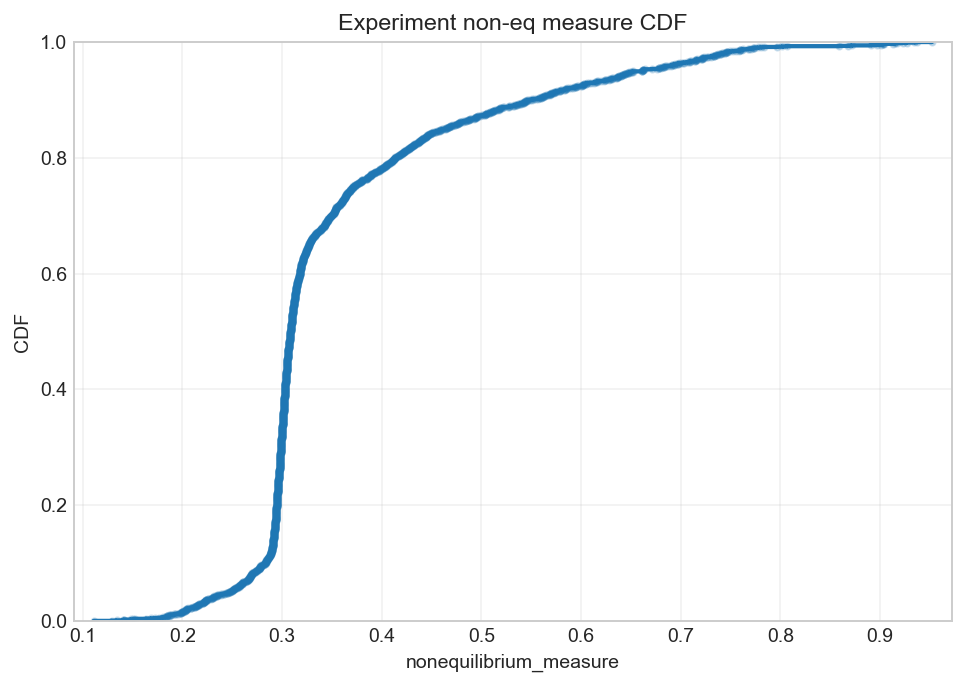

saved: /data1/bowenyu/XPCS_ODE/notebooks/outputs/experiment_non_eq_measure_cdf.png
saved: /data1/bowenyu/XPCS_ODE/notebooks/outputs/experiment_non_eq_measure_cdf.pdf


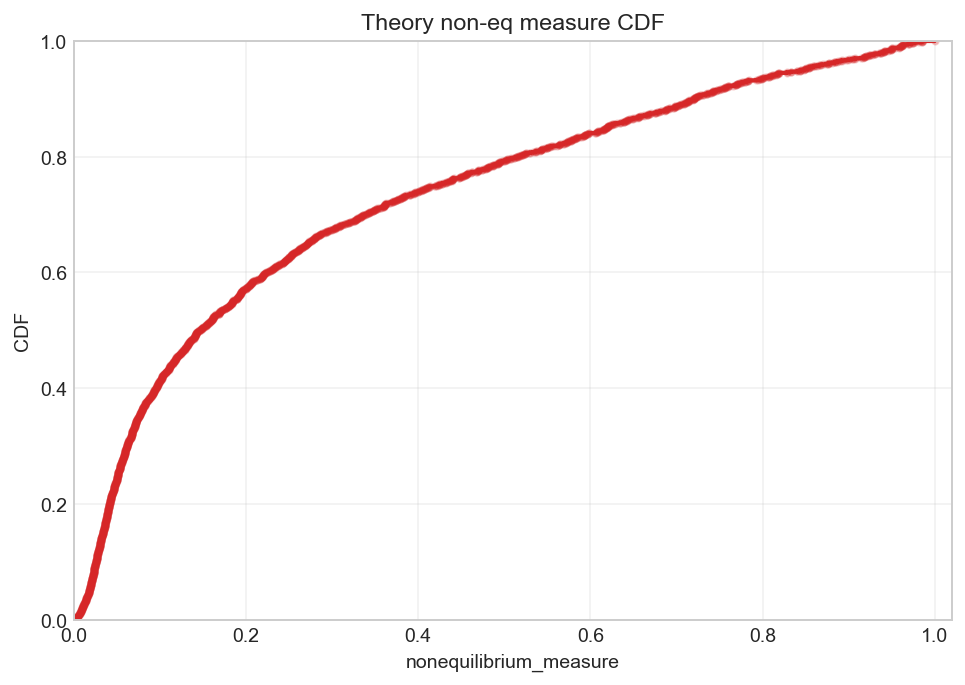

saved: /data1/bowenyu/XPCS_ODE/notebooks/outputs/theory_non_eq_measure_cdf.png
saved: /data1/bowenyu/XPCS_ODE/notebooks/outputs/theory_non_eq_measure_cdf.pdf


PosixPath('/data1/bowenyu/XPCS_ODE/notebooks/outputs/theory_non_eq_measure_cdf.png')

In [3]:
def ecdf(values: pd.Series) -> tuple[np.ndarray, np.ndarray]:
    x = np.sort(values.to_numpy(dtype=np.float64))
    y = np.arange(1, len(x) + 1, dtype=np.float64) / len(x)
    return x, y


def plot_cdf(values: pd.Series, title: str, color: str, stem: str) -> Path:
    x, y = ecdf(values)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.step(x, y, where="post", color=color, linewidth=2.2)
    ax.scatter(x, y, color=color, s=10, alpha=0.22)
    ax.set_title(title)
    ax.set_xlabel("nonequilibrium_measure")
    ax.set_ylabel("CDF")
    ax.set_xlim(max(0.0, float(x.min()) - 0.02), min(1.02, float(x.max()) + 0.02))
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    png_path = OUTPUT_DIR / f"{stem}.png"
    pdf_path = OUTPUT_DIR / f"{stem}.pdf"
    fig.savefig(png_path, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"saved: {png_path}")
    print(f"saved: {pdf_path}")
    return png_path


plot_cdf(
    exp_values,
    title="Experiment non-eq measure CDF",
    color="#1f77b4",
    stem="experiment_non_eq_measure_cdf",
)

plot_cdf(
    sim_values,
    title="Theory non-eq measure CDF",
    color="#d62728",
    stem="theory_non_eq_measure_cdf",
)


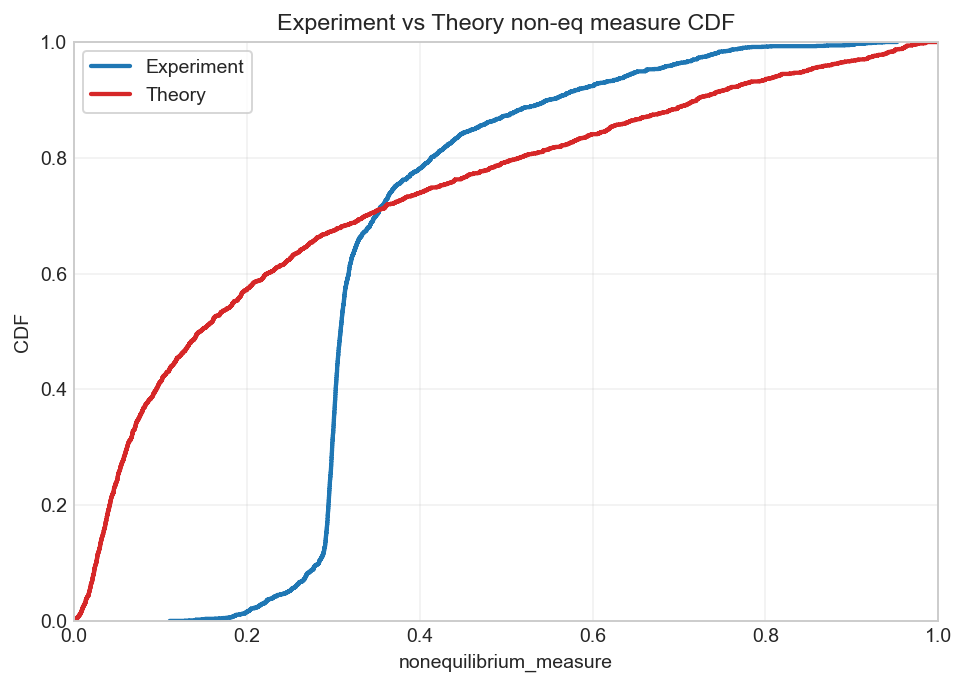

saved: /data1/bowenyu/XPCS_ODE/notebooks/outputs/experiment_vs_theory_non_eq_measure_cdf.png
saved: /data1/bowenyu/XPCS_ODE/notebooks/outputs/experiment_vs_theory_non_eq_measure_cdf.pdf


In [4]:
exp_x, exp_y = ecdf(exp_values)
sim_x, sim_y = ecdf(sim_values)

fig, ax = plt.subplots(figsize=(7, 5))
ax.step(exp_x, exp_y, where="post", color="#1f77b4", linewidth=2.2, label="Experiment")
ax.step(sim_x, sim_y, where="post", color="#d62728", linewidth=2.2, label="Theory")
ax.set_title("Experiment vs Theory non-eq measure CDF")
ax.set_xlabel("nonequilibrium_measure")
ax.set_ylabel("CDF")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.grid(True, alpha=0.3)
ax.legend(frameon=True)
fig.tight_layout()

overlay_png_path = OUTPUT_DIR / "experiment_vs_theory_non_eq_measure_cdf.png"
overlay_pdf_path = OUTPUT_DIR / "experiment_vs_theory_non_eq_measure_cdf.pdf"
fig.savefig(overlay_png_path, bbox_inches="tight")
fig.savefig(overlay_pdf_path, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"saved: {overlay_png_path}")
print(f"saved: {overlay_pdf_path}")
